In [1]:
"""
Part 2 — Regression and Classification Modeling
Dataset: cleaned_data.csv (output of preprocessing1.ipynb)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score
)

In [2]:
# 1. Loading  data and defining labels

df = pd.read_csv("data/cleaned_data.csv")

In [3]:
# Regression target: continuous house value
y_reg = df["median_house_value"]

# Classification target: 'expensive' is already a binary column created in 'preprocessing1.ipynb' 
y_clf = df["expensive"]

# Feature matrix: Dropping both targets AND median_house_value to avoid leakage
X = df.drop(columns=["median_house_value", "expensive"])

print("X shape:", X.shape)
print("y_reg preview:\n", y_reg.head())
print("y_clf value counts:\n", y_clf.value_counts())

X shape: (20640, 14)
y_reg preview:
 0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64
y_clf value counts:
 expensive
0    10323
1    10317
Name: count, dtype: int64


In [4]:
# 2. Encoding categorical columns

# 'income_category' has a natural order: Low < Medium < High < Very High (Label Encoding)

order_map = {"Low": 0, "Medium": 1, "High": 2, "Very High": 3}
X["income_category"] = X["income_category"].map(order_map)

# ocean_proximity has no natural order (nominal categories) (One-Hot Encoding)

X = pd.get_dummies(X, columns=["ocean_proximity"], drop_first=True)

print("\nColumns after encoding:")
print(X.columns.tolist())


Columns after encoding:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'is_value_capped', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_category', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [5]:
# 3. Leak-free train-test split and scaling
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(X, y_reg, y_clf, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
# 4. Regression model — Linear Regression

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_reg_train)

y_pred_reg = lin_reg.predict(X_test_scaled)

mse_lin = mean_squared_error(y_reg_test, y_pred_reg)
r2_lin = r2_score(y_reg_test, y_pred_reg)

print(f"\nLinear Regression -> MSE: {mse_lin:,.2f}  R2: {r2_lin:.4f}")

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_reg.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

print("\nLinear Regression coefficients (sorted by |value|):")
print(coef_table)

print("\nTop 3 features by |coefficient|:")
print(coef_table.head(3))


Linear Regression -> MSE: 4,177,100,818.18  R2: 0.6812

Linear Regression coefficients (sorted by |value|):
                       feature   coefficient
1                     latitude -53461.271095
0                    longitude -53299.101845
5                   population -40287.791328
6                   households  39478.392721
8              is_value_capped  32983.035488
7                median_income  32147.457359
12             income_category  32066.501054
13      ocean_proximity_INLAND -17464.431123
10           bedrooms_per_room  12937.043887
2           housing_median_age  10196.372315
9          rooms_per_household   6897.688047
3                  total_rooms   5645.971179
14      ocean_proximity_ISLAND   2107.527612
15    ocean_proximity_NEAR BAY  -2016.003889
11    population_per_household   1183.230437
16  ocean_proximity_NEAR OCEAN    161.093656
4               total_bedrooms     62.216655

Top 3 features by |coefficient|:
      feature   coefficient
1    latitude -5346

In [7]:
# 4b. Ridge Regression
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_scaled, y_reg_train)

y_pred_ridge = ridge_reg.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

print(f"\nRidge Regression   -> MSE: {mse_ridge:,.2f}  R2: {r2_ridge:.4f}")

comparison_table = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge (alpha=1.0)"],
    "MSE": [mse_lin, mse_ridge],
    "R2": [r2_lin, r2_ridge]
})
print("\nModel comparison table:")
display(comparison_table)


Ridge Regression   -> MSE: 4,176,963,555.16  R2: 0.6812

Model comparison table:


,Model,MSE,R2
0,Linear Regression,4.177101e+09,0.681237
1,Ridge (alpha=1.0),4.176964e+09,0.681247


In [8]:
# 5. Classification model — Logistic Regression

class_counts = y_clf_train.value_counts(normalize=True)
print("\nClass balance in training set:")
print(class_counts)

minority_share = class_counts.min()

if minority_share < 0.35:
    # Imbalance handling: use class_weight='balanced'
    print(f"\nMinority class share = {minority_share:.2%} (< 35%) -> using class_weight='balanced'")
    log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
else:
    print(f"\nMinority class share = {minority_share:.2%} (>= 35%) -> no resampling needed")
    log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_scaled, y_clf_train)

y_pred_clf = log_reg.predict(X_test_scaled)
y_proba_clf = log_reg.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_clf_test, y_pred_clf)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_clf_test, y_pred_clf))

fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba_clf)
auc_score = roc_auc_score(y_clf_test, y_proba_clf)
print(f"\nAUC: {auc_score:.4f}")


Class balance in training set:
expensive
1    0.500606
0    0.499394
Name: proportion, dtype: float64

Minority class share = 49.94% (>= 35%) -> no resampling needed

Confusion Matrix:
 [[1739  338]
 [ 328 1723]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84      2077
           1       0.84      0.84      0.84      2051

    accuracy                           0.84      4128
   macro avg       0.84      0.84      0.84      4128
weighted avg       0.84      0.84      0.84      4128


AUC: 0.9155


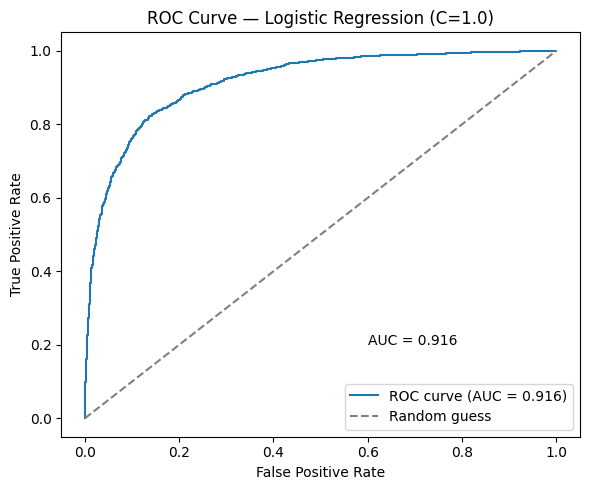

In [9]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (C=1.0)")
plt.annotate(f"AUC = {auc_score:.3f}", xy=(0.6, 0.2))
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# 5b. Decision-threshold sensitivity

thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results = []

for t in thresholds_to_test:
    y_pred_t = (y_proba_clf >= t).astype(int)
    precision_t = precision_score(y_clf_test, y_pred_t)
    recall_t = recall_score(y_clf_test, y_pred_t)
    f1_t = f1_score(y_clf_test, y_pred_t)
    threshold_results.append([t, precision_t, recall_t, f1_t])

threshold_table = pd.DataFrame(
    threshold_results, columns=["Threshold", "Precision", "Recall", "F1"]
)
print("\nThreshold sensitivity table:")
print(threshold_table)

best_threshold_row = threshold_table.loc[threshold_table["F1"].idxmax()]
print(f"\nBest F1-score at threshold = {best_threshold_row['Threshold']}, "
      f"F1 = {best_threshold_row['F1']:.4f}")


Threshold sensitivity table:
   Threshold  Precision    Recall        F1
0        0.3   0.755110  0.918576  0.828861
1        0.4   0.798678  0.883959  0.839158
2        0.5   0.836002  0.840078  0.838035
3        0.6   0.874388  0.784008  0.826735
4        0.7   0.899258  0.709410  0.793132

Best F1-score at threshold = 0.4, F1 = 0.8392


In [11]:
# 6. Regularization experiment: C=0.01 vs C=1.0

log_reg_strong_reg = LogisticRegression(max_iter=1000, C=0.01, class_weight=log_reg.class_weight)
log_reg_strong_reg.fit(X_train_scaled, y_clf_train)

y_pred_strong = log_reg_strong_reg.predict(X_test_scaled)
y_proba_strong = log_reg_strong_reg.predict_proba(X_test_scaled)[:, 1]

precision_baseline = precision_score(y_clf_test, y_pred_clf)
recall_baseline = recall_score(y_clf_test, y_pred_clf)
auc_baseline = auc_score

precision_strong = precision_score(y_clf_test, y_pred_strong)
recall_strong = recall_score(y_clf_test, y_pred_strong)
auc_strong = roc_auc_score(y_clf_test, y_proba_strong)

reg_comparison_table = pd.DataFrame({
    "Model": ["C=1.0 (baseline)", "C=0.01 (strong regularization)"],
    "Precision": [precision_baseline, precision_strong],
    "Recall": [recall_baseline, recall_strong],
    "AUC": [auc_baseline, auc_strong]
})
print("\nRegularization comparison table:")
print(reg_comparison_table)


Regularization comparison table:
                            Model  Precision    Recall       AUC
0                C=1.0 (baseline)   0.836002  0.840078  0.915549
1  C=0.01 (strong regularization)   0.810709  0.841541  0.909532


In [12]:
# 7. Bootstrap confidence interval for AUC difference
n_bootstrap = 500
auc_differences = []

y_clf_test_array = y_clf_test.reset_index(drop=True)

np.random.seed(42)  # for reproducibility

for i in range(n_bootstrap):
    sample_idx = np.random.choice(len(y_clf_test_array), size=len(y_clf_test_array), replace=True)

    y_sample = y_clf_test_array.iloc[sample_idx]
    proba_baseline_sample = y_proba_clf[sample_idx]
    proba_strong_sample = y_proba_strong[sample_idx]

    auc_baseline_sample = roc_auc_score(y_sample, proba_baseline_sample)
    auc_strong_sample = roc_auc_score(y_sample, proba_strong_sample)

    auc_differences.append(auc_baseline_sample - auc_strong_sample)

auc_differences = np.array(auc_differences)

mean_diff = auc_differences.mean()
ci_lower = np.percentile(auc_differences, 2.5)
ci_upper = np.percentile(auc_differences, 97.5)

print(f"\nBootstrap AUC difference (C=1.0 minus C=0.01):")
print(f"Mean difference: {mean_diff:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")


Bootstrap AUC difference (C=1.0 minus C=0.01):
Mean difference: 0.0060
95% CI: [0.0037, 0.0085]


In [13]:
if ci_lower > 0 or ci_upper < 0:
    print("The 95% CI excludes zero -> the C=1.0 model's advantage is likely consistent.")
else:
    print("The 95% CI includes zero -> the difference may not be reliable.")

The 95% CI excludes zero -> the C=1.0 model's advantage is likely consistent.
